In [ ]:
# CardioGoodFitness - Customer Treadmill Purchase Analysis

In [29]:
## Problem Statement

The objective of this project is to analyze the customer data of CardioGoodFitness company to understand the relationship between customer demographics such as Age, Gender, Income, Fitness Level, Usage, and the treadmill product purchased (TM195, TM498, TM798).

This analysis helps in identifying customer behavior and assists the company in making better marketing and product placement decisions.   

In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
#load dataset

In [4]:
mydata=pd.read_csv('D:\CardioGoodFitness\CardioGoodFitness.csv')
mydata.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,18,Male,14,Single,3,4,29562,112
1,TM195,19,Male,15,Single,2,3,31836,75
2,TM195,19,Female,14,Partnered,4,3,30699,66
3,TM195,19,Male,12,Single,3,3,32973,85
4,TM195,20,Male,13,Partnered,4,2,35247,47


In [34]:
## Data Cleaning

In this step, we check for:

- Missing values  
- Duplicate values  
- Data types of each column  
- Overall dataset structure  

In [35]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [36]:
mydata.isnull().sum()

Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

In [37]:
mydata.duplicated().sum()

np.int64(0)

In [38]:
## Descriptive Statistics
Descriptive statistics help us understand the central tendency and spread of the dataset using measures such as mean, median, and standard deviation.

In [39]:
mydata.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


In [40]:
## Exploratory Data Analysis (EDA)
EDA is used to visualize and understand patterns, trends, and relationships between different variables in the dataset.

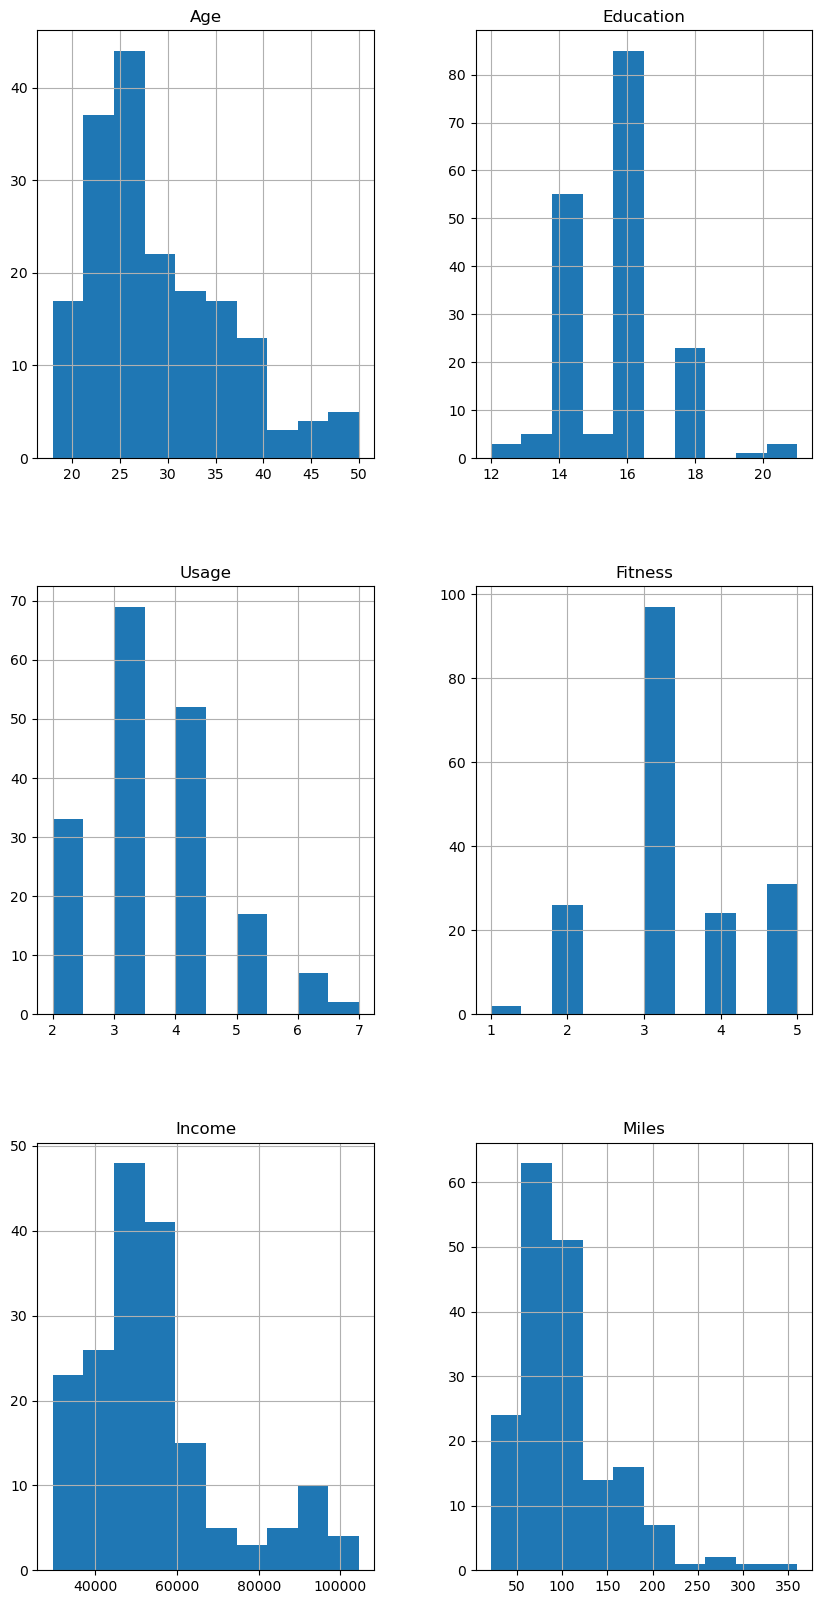

In [41]:
#Histogram
mydata.hist(figsize=(10,20))
plt.show()

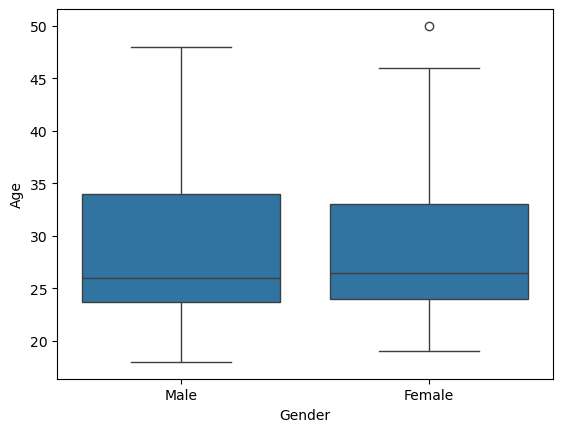

In [42]:
#Boxplot
sns.boxplot(x="Gender",y="Age", data=mydata)
plt.show()

In [5]:
pd.crosstab(mydata['Product'],mydata['Gender'] )

Gender,Female,Male
Product,,
TM195,40,40
TM498,29,31
TM798,7,33


In [6]:
pd.crosstab(mydata['Product'],mydata['MaritalStatus'] )

MaritalStatus,Partnered,Single
Product,,
TM195,48,32
TM498,36,24
TM798,23,17


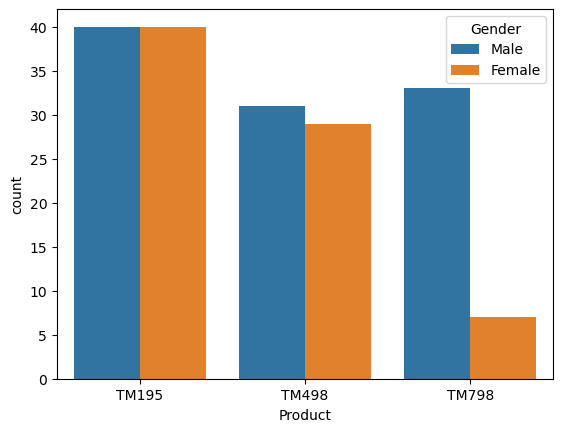

In [18]:
#countplot - product vs gender
sns.countplot(x="Product" ,hue="Gender", data=mydata)
plt.show()

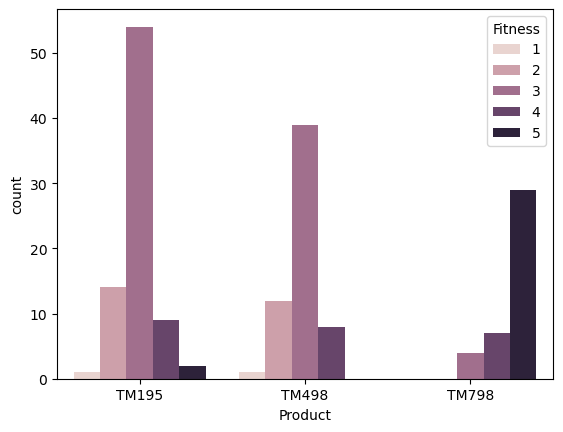

In [19]:
#countplot - product vs fitness
sns.countplot(x="Product" ,hue="Fitness", data=mydata)
plt.show()

In [7]:
pd.pivot_table(mydata, index=['Product', 'Gender'],
                     columns=[ 'MaritalStatus'], aggfunc=len)

Age        Education          Fitness           Income  \
MaritalStatus  Partnered Single Partnered Single Partnered Single Partnered   
Product Gender                                                                
TM195   Female        27     13        27     13        27     13        27   
        Male          21     19        21     19        21     19        21   
TM498   Female        15     14        15     14        15     14        15   
        Male          21     10        21     10        21     10        21   
TM798   Female         4      3         4      3         4      3         4   
        Male          19     14        19     14        19     14        19   

                          Miles            Usage         
MaritalStatus  Single Partnered Single Partnered Single  
Product Gender                                           
TM195   Female     13        27     13        27     13  
        Male       19        21     19        21     19  
TM498   Female     14        15     14        15     14  
        Male       10        21     10        21     10  
TM798   Female      3         4      3         4      3  
        Male       14        19     14        19     14

In [8]:
pd.pivot_table(mydata,'Income', index=['Product', 'Gender'],
                     columns=[ 'MaritalStatus'])

MaritalStatus      Partnered        Single
Product Gender                            
TM195   Female  46153.777778  45742.384615
        Male    50028.000000  43265.842105
TM498   Female  49724.800000  48920.357143
        Male    49378.285714  47071.800000
TM798   Female  84972.250000  58516.000000
        Male    81431.368421  68216.428571

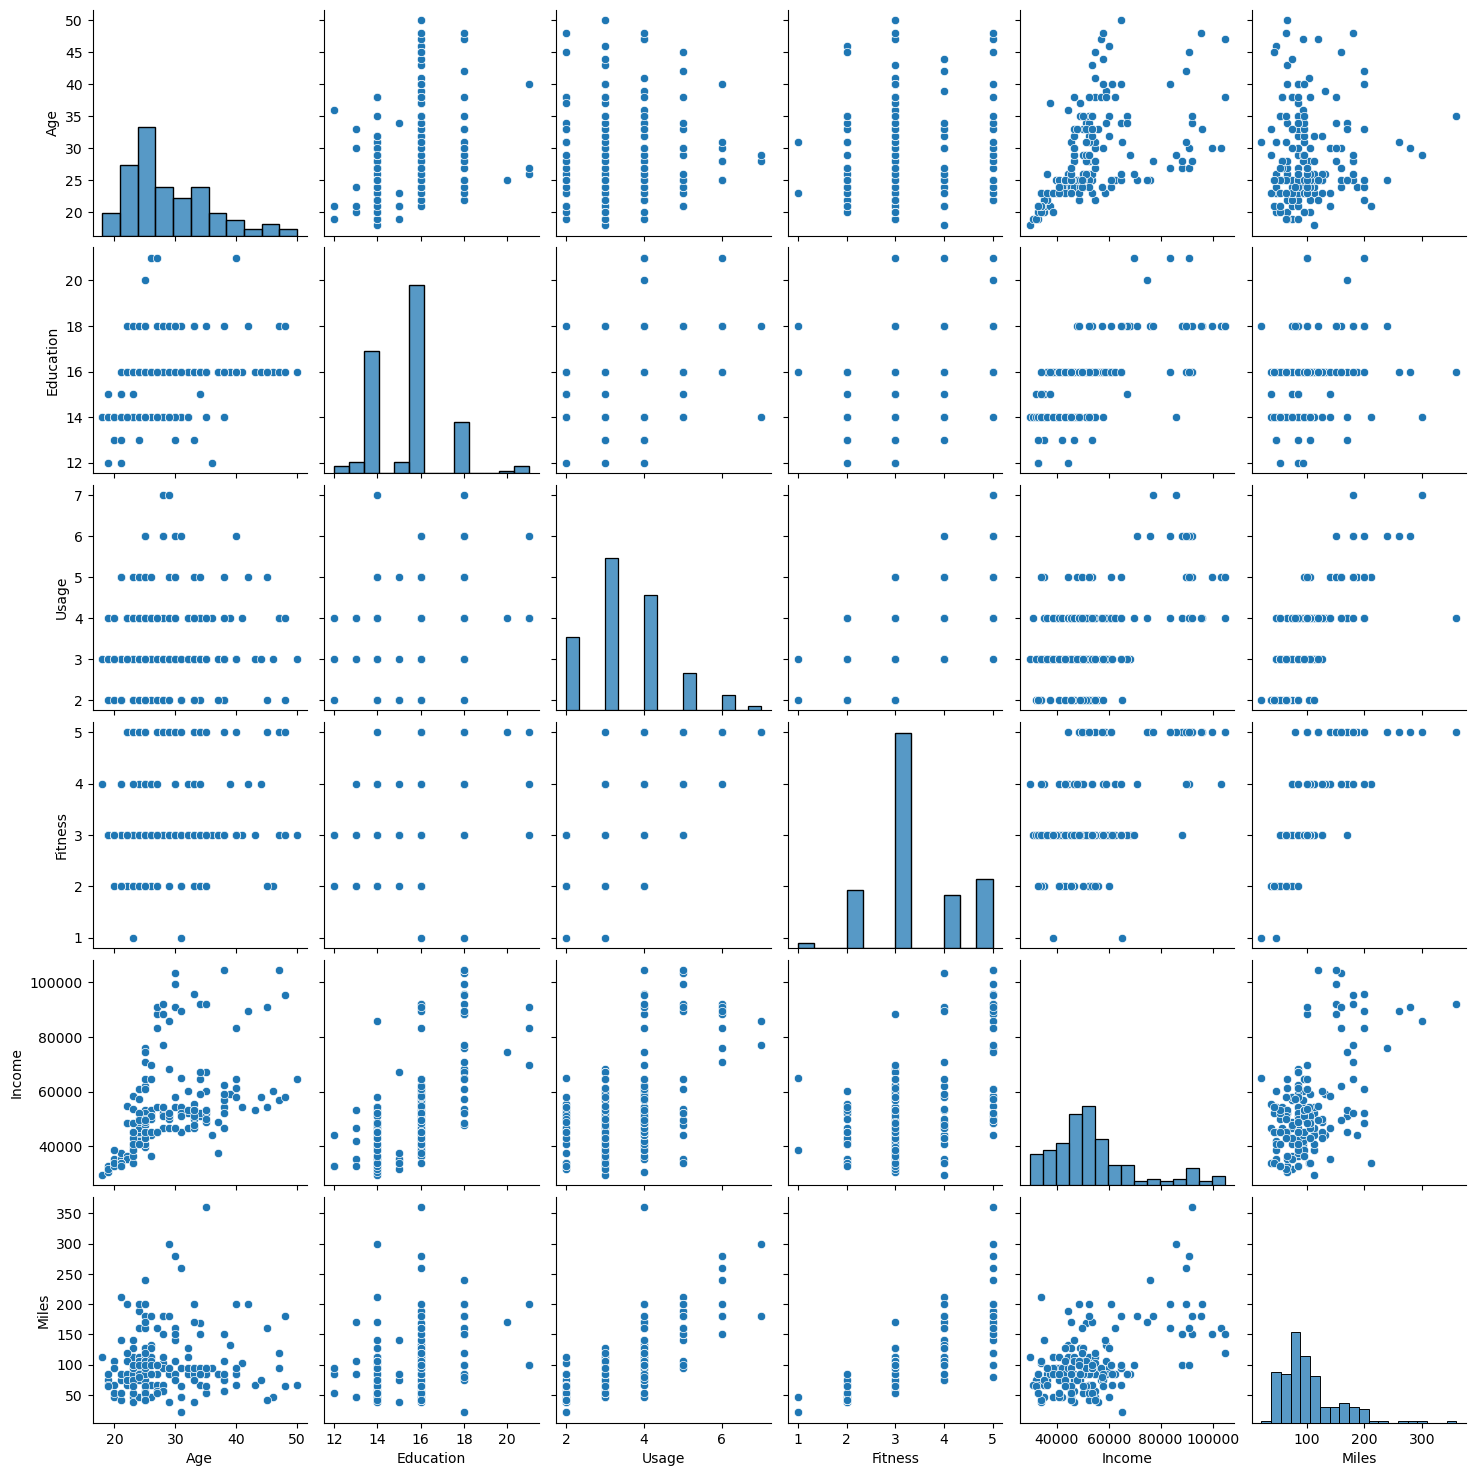

In [12]:
sns.pairplot(mydata)

In [13]:
mydata['Age'].std()

6.943498135399795

In [14]:
mydata['Age'].mean()

np.float64(28.788888888888888)

<Axes: xlabel='Age', ylabel='Count'>

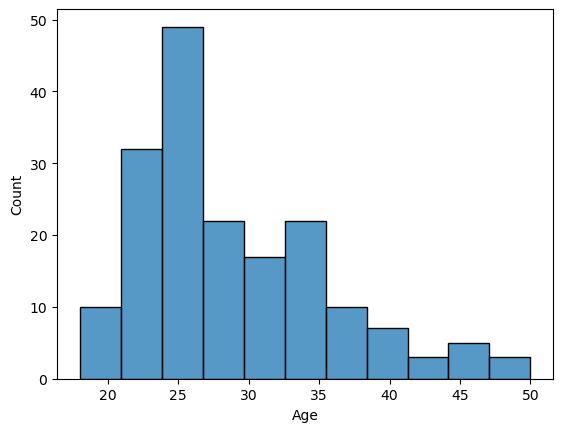

In [16]:
#Age distribution
sns.histplot(mydata['Age'])

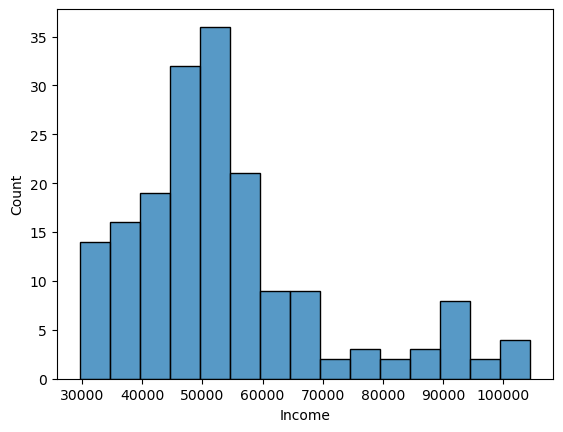

In [26]:
#income distribution
sns.histplot(mydata["Income"])
plt.show()

array([<Axes: title={'center': 'Female'}>,
       <Axes: title={'center': 'Male'}>], dtype=object)

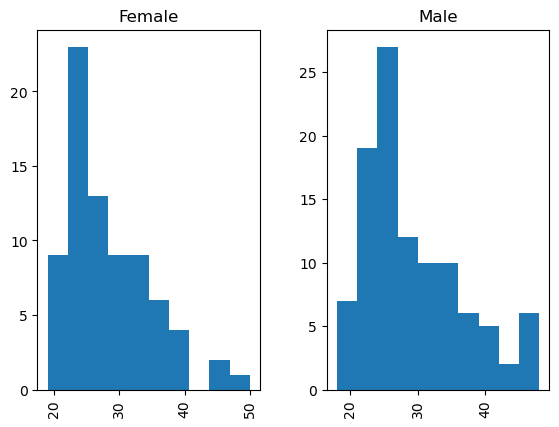

In [17]:
mydata.hist(by='Gender',column = 'Age')

array([<Axes: title={'center': 'Female'}>,
       <Axes: title={'center': 'Male'}>], dtype=object)

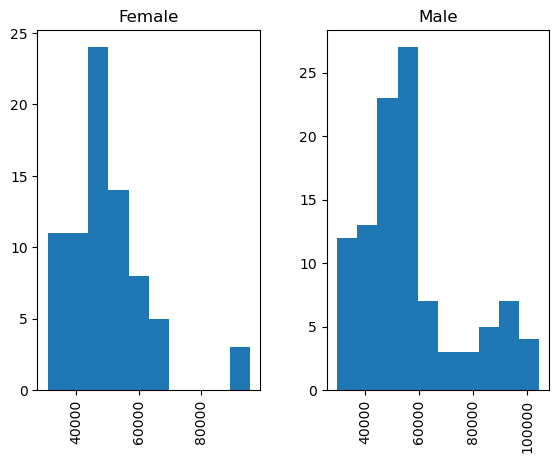

In [18]:
mydata.hist(by='Gender',column = 'Income')

array([<Axes: title={'center': 'Female'}>,
       <Axes: title={'center': 'Male'}>], dtype=object)

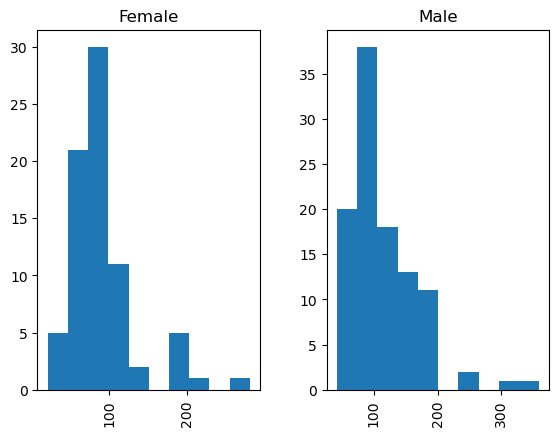

In [19]:
mydata.hist(by='Gender',column = 'Miles')

array([[<Axes: title={'center': 'TM195'}>,
        <Axes: title={'center': 'TM498'}>],
       [<Axes: title={'center': 'TM798'}>, <Axes: >]], dtype=object)

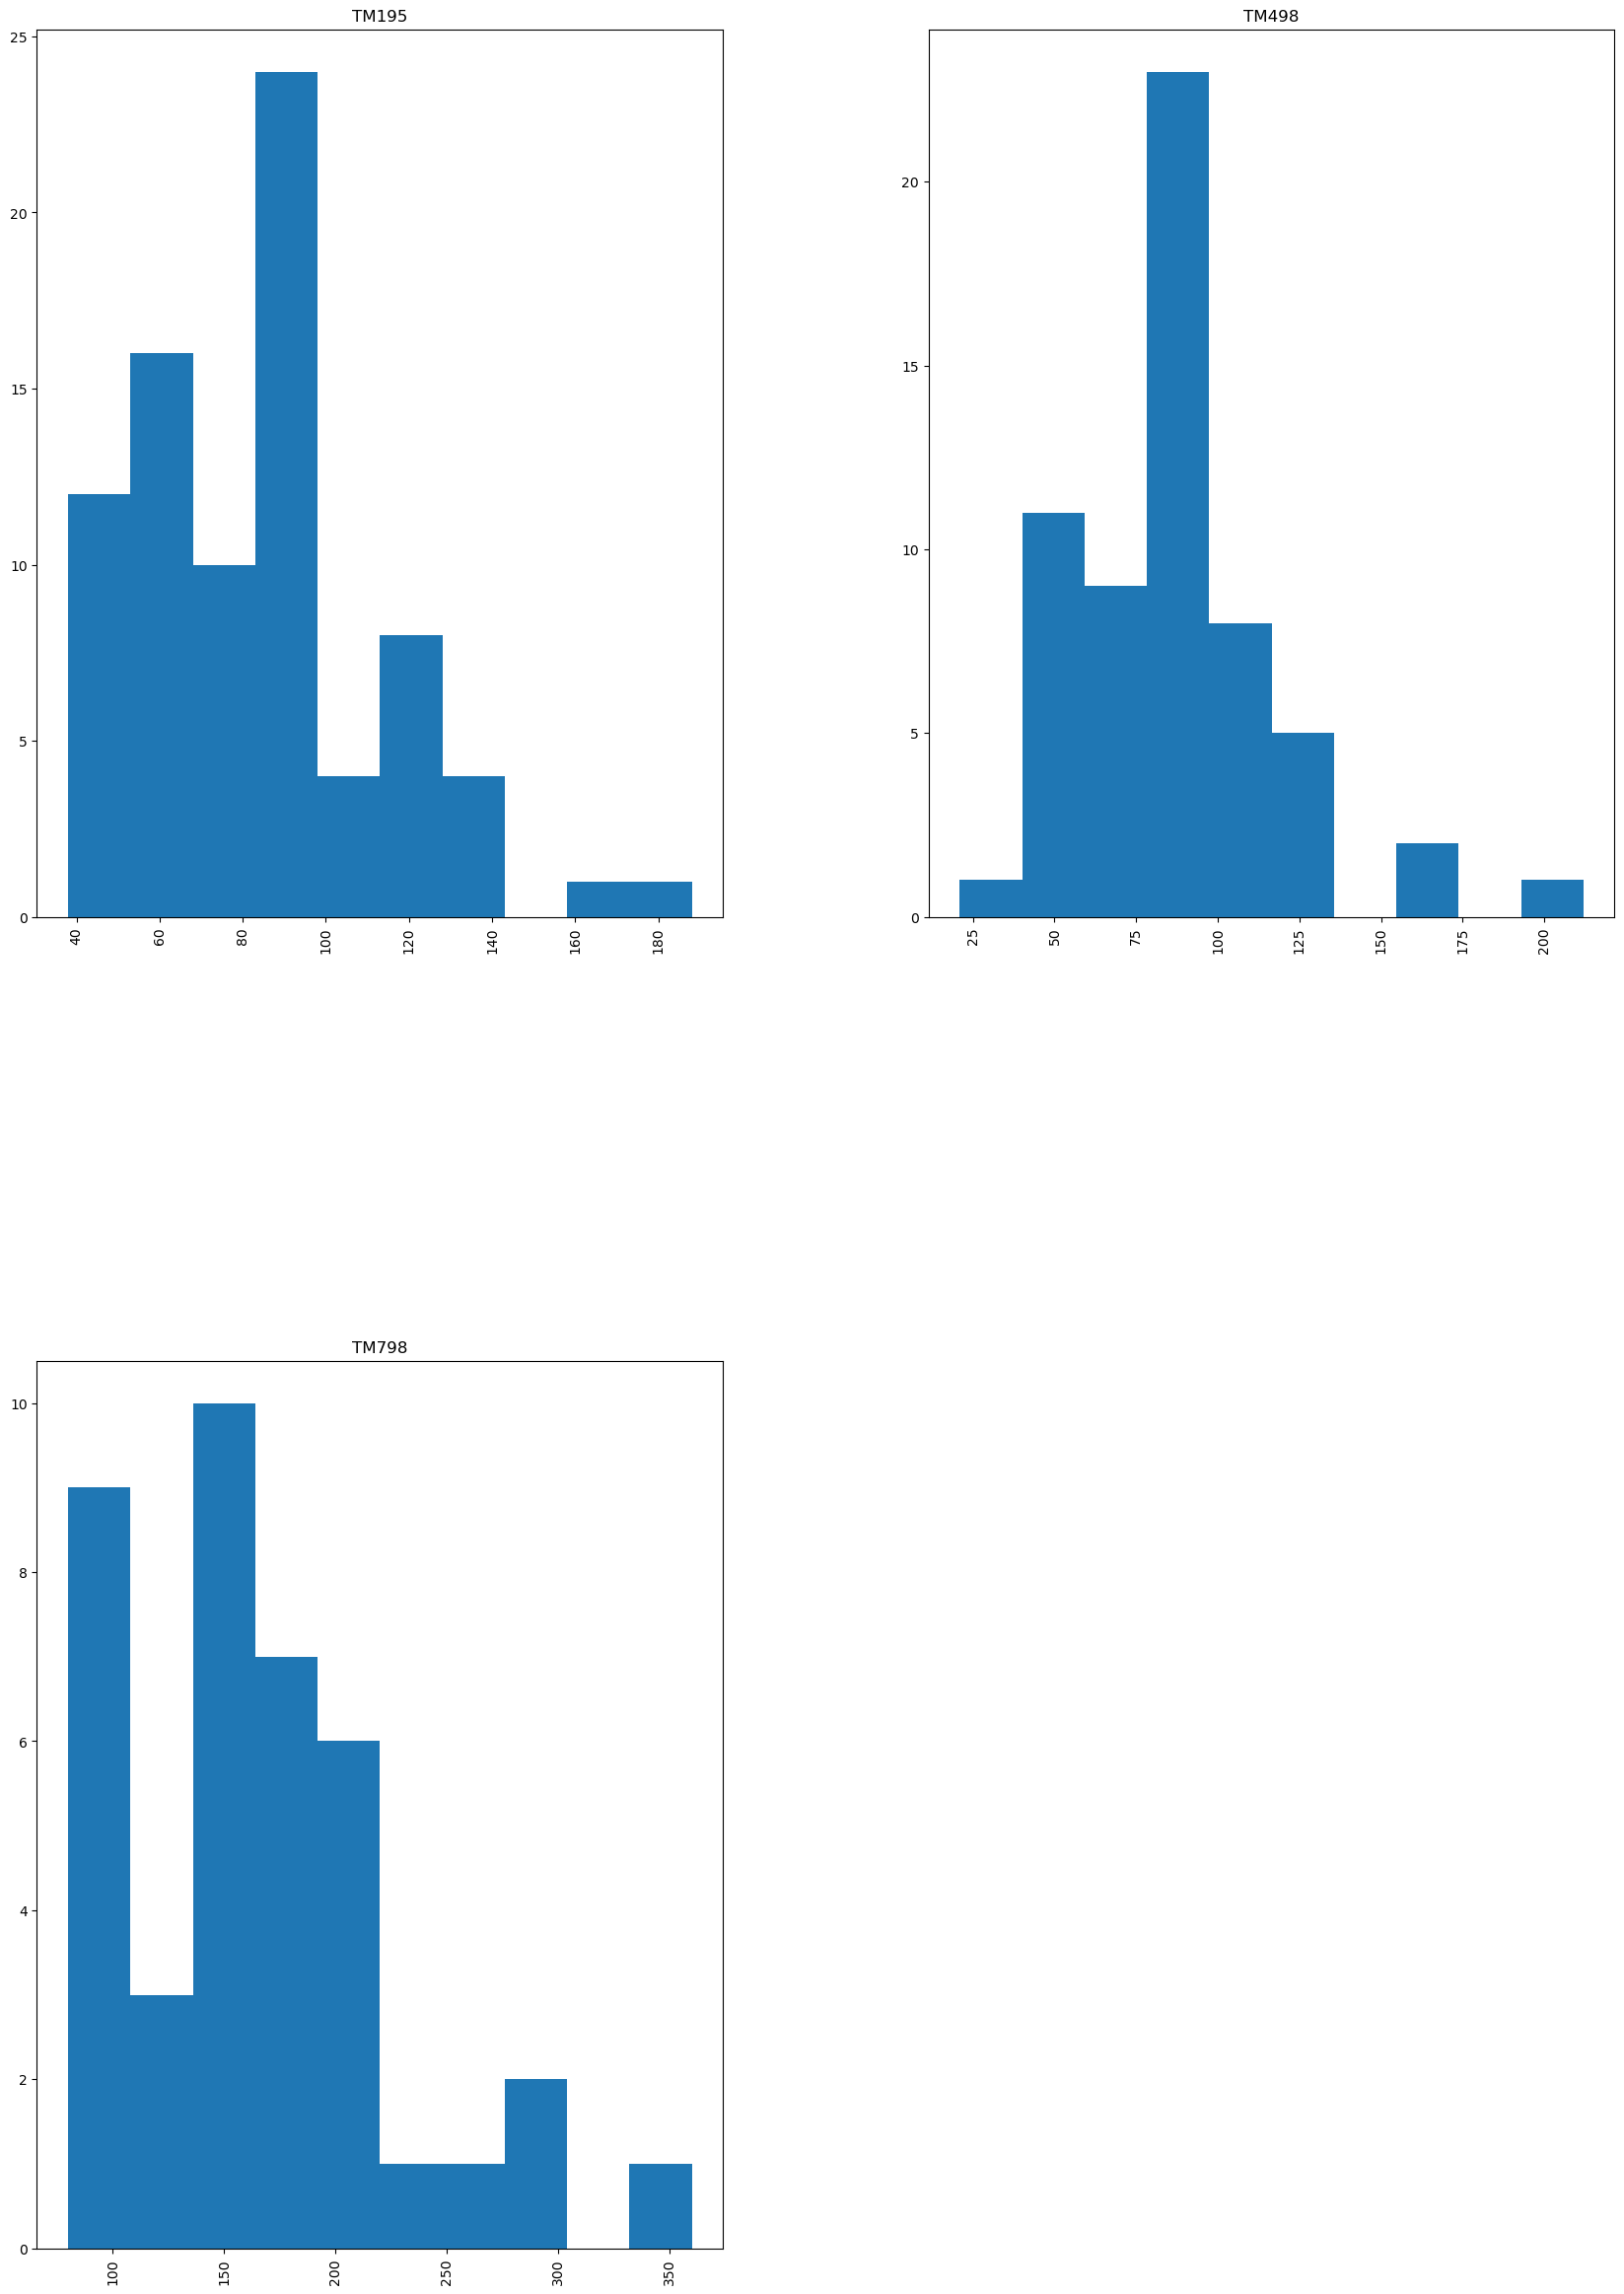

In [20]:
mydata.hist(by='Product',column = 'Miles', figsize=(20,30))

In [23]:
corr = mydata.corr(numeric_only=True)
corr

,Age,Education,Usage,Fitness,Income,Miles
Age,1.000000,0.280496,0.015064,0.061105,0.513414,0.036618
Education,0.280496,1.000000,0.395155,0.410581,0.625827,0.307284
Usage,0.015064,0.395155,1.000000,0.668606,0.519537,0.759130
Fitness,0.061105,0.410581,0.668606,1.000000,0.535005,0.785702
Income,0.513414,0.625827,0.519537,0.535005,1.000000,0.543473
Miles,0.036618,0.307284,0.759130,0.785702,0.543473,1.000000


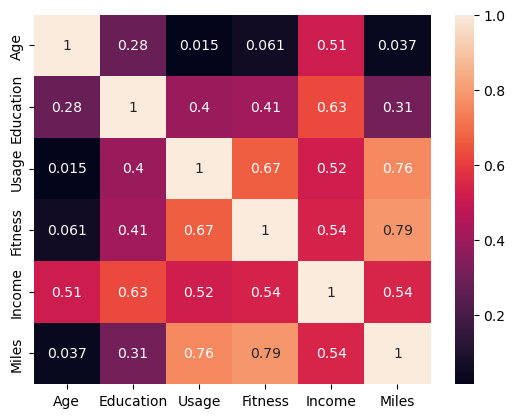

In [47]:
sns.heatmap(mydata.corr(numeric_only=True), annot=True)
plt.show()

In [24]:
#Load function from sklearn
from sklearn import linear_model

# Create linear regression object
regr = linear_model.LinearRegression()

y = mydata['Miles']
x = mydata[['Usage','Fitness']]

# Train the model using the training sets
regr.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
regr.coef_

array([20.21486334, 27.20649954])

In [26]:
regr.intercept_

np.float64(-56.74288178464862)

In [27]:
# MilesPredicted = -56.74 + 20.21*Usage + 27.20*Fitness

In [ ]:
#Insights / Observations
- Customer aged between 25 - 35 are the primary buyers of treadmills.
- TM195 is mostly purchased by customers wth low fitness level.
- TM798 is prefered by high income and advnaced fitness levels.
- male customers teends to use treadmills more  frequently than female  customers.
- customer with higher income can more likely to purchase TM798.

In [ ]:
#Conclusion
Income level, Fitness level, Usage frequency significantly influence treadmill purchases.
TM195 is suitable for beginners, TM498 for intermediate users and TM798 for advancd users.

In [ ]:
## Business Recommendations

• High-income customers prefer TM798. Marketing campaigns for TM798 should target premium customer segments.

• TM195 is mostly purchased by beginner fitness users. It can be promoted as an entry-level treadmill.

• Customers with higher weekly usage are more likely to purchase TM798. Subscription-based offers can be introduced for these customers.

• Age group 25–35 shows higher purchasing behavior. This group should be targeted in promotional activities.